### 목표설정
- 손글씨 숫자(0~9)를 분류하는 모델을 만들어보자
- 이미지 데이터의 형태를 이해해보자
- 분류 모델의 불확실성에 대해 이해해보자

In [31]:
# 필요한 라이브러리 불러오기
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [32]:
# 데이터 불러오기
digit_data = pd.read_csv('./data/digit_train.csv')
digit_data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
digit_data

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41996,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41997,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
41998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
# 데이터 살펴보기
# label : 0 ~ 9까지 숫자가 들어있는 컬럼(손글씨가 무슨 숫자인가?) - 정답
# pixel0 ~ pixel783 : 784개 픽셀 고유값이 들어있는 컬럼 - 문제
digit_data.shape # 데이터 42,000개가 들어있는 데이터
# 이 데이터는 이미지를 표로 바꿔둔 데이터
# 데이터에 대한 정보를 알아보자

(42000, 785)

흑백 이미지 -> 색상 채널 X (2차원 데이터로 구성)
> (Y, X) = (세로축(행), 가로축(열))

컬러 이미지 -> 색상 채널 O (3차원 데이터로 구성)
> (Y, X, C) = (세로축(행), 가로축(열), 색상채널(R,G,B))

In [12]:
# 우리가 가지고 있는 현재 데이터 -> 2차원의 흑백 이미지 데이터 -> 1차원의 형태로 만들어 놓은것
# 42000 : 이미지의 개수
# 785 : 정답포함 이미지를 1차원으로 변환해둔 데이터

# 데이터 하나를 뽑아서 이미지의 형태를 살펴보자.
# img0에 담긴 데이터는 pandas.Series형태의 1차원구조
img0 = digit_data.iloc[0, 1:]
img0

pixel0      0
pixel1      0
pixel2      0
pixel3      0
pixel4      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Name: 0, Length: 784, dtype: int64

In [13]:
# 값의 최대값 / 최소값 살펴보기
print(img0.max())
print(img0.min())

255
0


In [34]:
# 현재 데이터는 784개의 픽셀을 1열로 정리해둔 데이터
# 원본데이터의 사이즈는 행과 열이 28개의 픽셀값으로 정리가 되는 2차원 데이터
img0.values.reshape(28,28)

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 220, 179,   6,   0,   0,   0,   0,
          0,   0,   0,   0,   9,  77,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

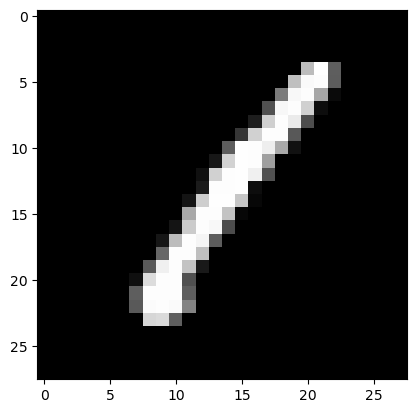

In [15]:
# 현재 일렬로 나열된 데이터를 2차원으로 변환
# 변환한 데이터를 활용해서 이미지를 그려봅시다.
# im -> 이미지를 보여줘라
plt.imshow(img0.values.reshape(28,28), cmap='gray')
plt.show()

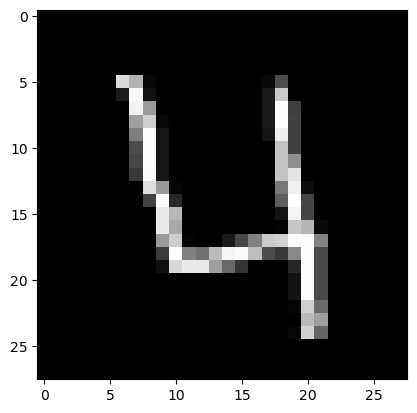

In [35]:
# 1개의 행을 선택해 전체 열(픽셀)의 값을 가져오자.
img0 = digit_data.iloc[3, 1:]
# 가져온 1개의 행의 형태를 2차원의 형태로 바꿔보자
plt.imshow(img0.values.reshape(28,28), cmap='gray')
plt.show()

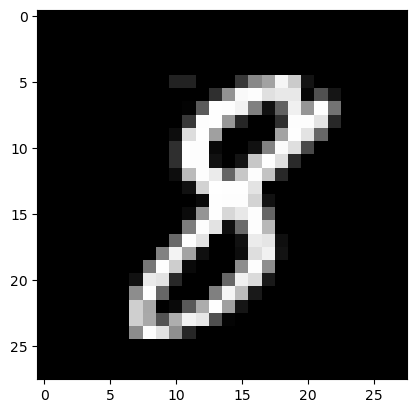

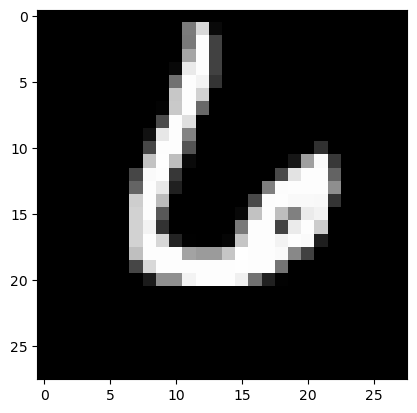

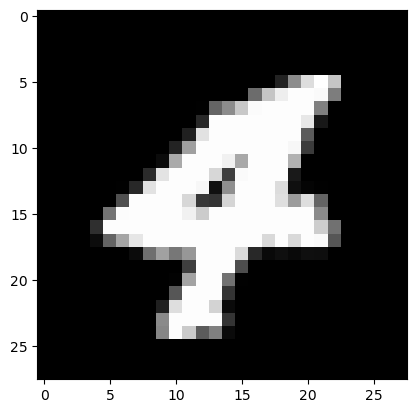

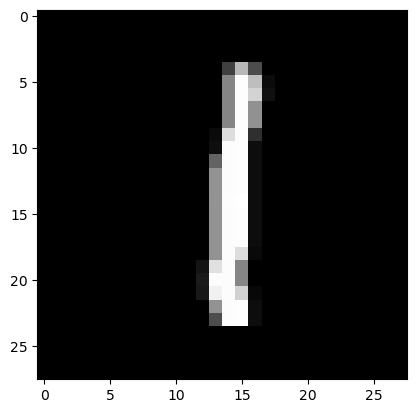

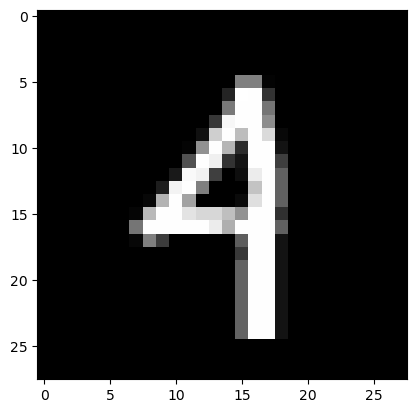

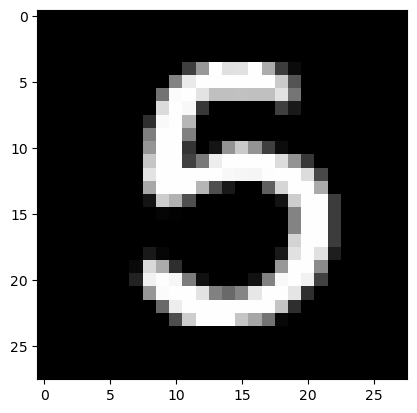

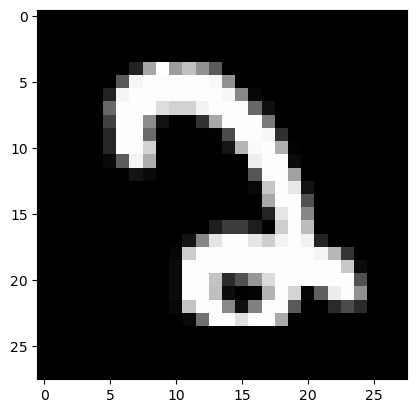

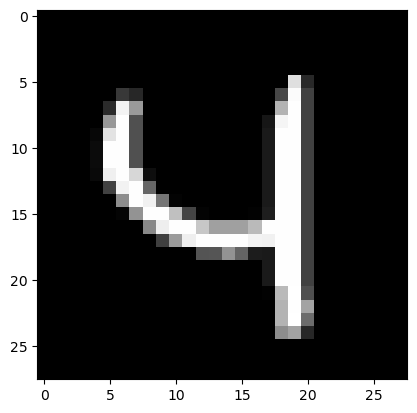

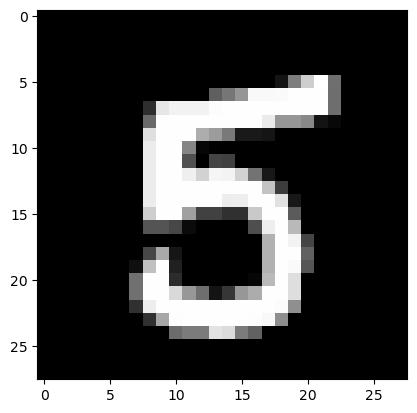

In [36]:
# 반복문으로 이미지 뽑아보기
# range(시작, 끝, 간격) - 끝값 포함X
for i in range(20, 42000, 5000):
    img0 = digit_data.iloc[i , 1:]
    plt.imshow(img0.values.reshape(28,28), cmap='gray')
    plt.show()

In [39]:
# 정답 데이터 살펴보기
# 정답 데이터의 고유값만 빼오기
# 현재 데이터 형태 -> 시리즈로
digit_data['label']

0        1
1        0
2        1
3        4
4        0
        ..
41995    0
41996    1
41997    7
41998    6
41999    9
Name: label, Length: 42000, dtype: int64

In [38]:
digit_data['label'].unique()

array([1, 0, 4, 7, 3, 5, 8, 9, 2, 6])

In [19]:
digit_data['label'].value_counts()

label
1    4684
7    4401
3    4351
9    4188
2    4177
6    4137
0    4132
4    4072
8    4063
5    3795
Name: count, dtype: int64

In [40]:
# 만약 label데이터가 배열이라면 고유값과 갯수를 어떻게 카운트 할 수 있을까?
arr_ = np.array(digit_data['label'])
arr_

array([1, 0, 1, ..., 7, 6, 9], shape=(42000,))

In [41]:
# 고유값을 보는 방법
np.unique(arr_)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [22]:
# 값별 개수를 카운트하는 방법
np.bincount(arr_)

array([4132, 4684, 4177, 4351, 4072, 3795, 4137, 4401, 4063, 4188])

In [42]:
np.unique(arr_, return_counts = True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([4132, 4684, 4177, 4351, 4072, 3795, 4137, 4401, 4063, 4188]))

In [3]:
# 데이터분할
X = digit_data.drop('label', axis = 1)
y = digit_data['label']

In [4]:
# train_test_split 함수 불러오기
from sklearn.model_selection import train_test_split

In [5]:
# 데이터 분할하기 / 테스트 비율 : 30% / 랜덤시드 7
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state=7,
                                                    test_size = 0.3)

In [6]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((29400, 784), (12600, 784), (29400,), (12600,))

In [7]:
# 모델 불러오기
from sklearn.linear_model import LogisticRegression

In [10]:
# 모델 객체 생성
logi = LogisticRegression(max_iter=10000, n_jobs = -1)

In [11]:
# 학습
logi.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [13]:
# 평가 - score
logi.score(X_test, y_test)

0.8836507936507937

### 지금까지 살펴본 모델
1. KNN
2. DecisionTree
3. 선형회귀 - 분석 방법이 맞지않음
4. 선형분류 - 실습 진행중

- 남은 KNN / DecisionTree모델도 사용해보자

In [14]:
# KNN 모델 사용해보기
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train , y_train)
knn.score(X_test, y_test)

0.9645238095238096

In [15]:
# DecisionTree
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
tree.score(X_test, y_test)

0.8553968253968254

### 분류의 불확실성

In [16]:
# 모델은 통계적인 계산을 통해 확률 정보를 확인하고, 확률 정보가 가장 높은 정답을 예측
# 분류 모델이 예측한 값에 대한 확률 정보를 확인해보자
knn.predict_proba(X_test)

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(12600, 10))

In [17]:
knn.predict_proba(X_test)[0]
# 왜 값이 10개 나오는가? -> 0 ~ 9까지 10개의 숫자
# 0처럼 생겼는가 아닌가? 
# -> 이 이미지가 0일 확률 0퍼센트
# -> 이 이미지가 1일 확률 100퍼센트

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

In [18]:
tree.predict_proba(X_test.iloc[0:3, :])

array([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

In [ ]:
# 임의로 답을 만들어서 확률 계산을 해봅시다.
# [0.4, 0.1, 0., 0., 0., 0., 0., 0., 0.5, 0.]
#   0   1    2   3   4   5   6   7   8    9

# 현재 예측된 값을 얼마이며 예측 확률이 가장 높은값은 얼마인가?
# 예측값은 8이고 예측확률은 50%이다.

# 전체 예측 확률의 값은 1.0(100%)에 해당하는 값을 가지고 있다.
# 예측 확률의 총합은 100% 이다.